In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [57]:
class KnnClassifier:
    
    def __init__(self, train_images, train_labels):
        self.train_images = train_images
        self.train_labels = train_labels

    def classify_image(self, test_image, num_neighbours = 3, metric = 'l2'):

        if metric == 'l2':
            dot = np.dot(test_image, self.train_images.T) # shape = (1,1000)
            test_sq = np.sum(test_image ** 2) # shape = (1,1)
            train_sq = np.sum(self.train_images ** 2, axis=1).reshape(1, -1) # shape = (1,1000)
            distances = np.sqrt(test_sq + train_sq - 2 * dot)
            #print(np.shape(distances))
            # print(distances)
        
        else: 
            if metric == 'l1':
                distances = np.sum(np.abs(train_images - test_image), axis = 1)
        distances = distances.flatten()
        indices = distances.argsort()[:num_neighbours]
        # distances = np.sort(distances)[:num_neighbours]

        # print(indices)

        predictions = self.train_labels[indices]

        p = np.argmax(np.bincount(predictions))
        return p
    def classify_images(self, test_images, nn, m):
        images = np.array([self.classify_image(test, num_neighbours = nn, metric = m) for test in test_images])
        return images

In [79]:
def accuracy_score(y_true, y_pred):
    return np.size(np.where(y_true == y_pred)) / np.size(y_true)


In [77]:

train_images = np.loadtxt('data_MNIST/data/train_images.txt') # incarcam imaginile
train_labels = np.loadtxt('data_MNIST/data/train_labels.txt').astype(np.int64) # incarcam etichetele avand tipul de date int

test_images = np.loadtxt('data_MNIST/data/test_images.txt')
test_labels = np.loadtxt('data_MNIST/data/test_labels.txt').astype(np.int64)

kcls = KnnClassifier(train_images, train_labels)
all_predictions = list()
for image in test_images:
    pred = kcls.classify_image(image)
    all_predictions.append(pred)
all_predictions = np.array(all_predictions)
np.savetxt('predictii_3nn_mnist.txt', all_predictions)

In [85]:

all_predictions = kcls.classify_images(test_images, 9, 'l2')
#print(all_predictions)
print(np.shape(all_predictions))



(500,)


In [87]:
acc = accuracy_score(test_labels, all_predictions)
print(f'Acuratetea este:{acc}\n')

Acuratetea este:0.88



In [89]:
def calc_accuracy_score(nn, m):
    predictions = kcls.classify_images(test_images, nn, m)
    acc = accuracy_score(test_labels, predictions)
    return acc
    

0.884
0.898
0.896
0.88
0.88


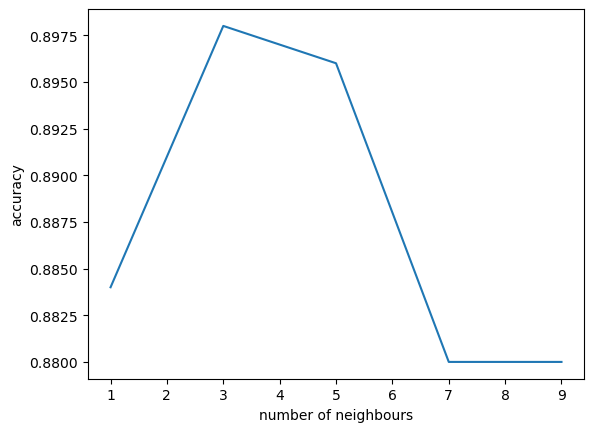

In [111]:
neighbours = np.array([1, 3, 5, 7, 9])
accuracies = list()
for n in neighbours:
    a = calc_accuracy_score(n, 'l2')
    accuracies.append(a)

accuracies = np.array(accuracies)
np.savetxt('acuratete_l2.txt', accuracies, fmt='%1.5f')

plt.plot(neighbours, accuracies)
plt.xlabel('number of neighbours')
plt.ylabel('accuracy')
plt.show()

0.88
0.884
0.868
0.864
0.864


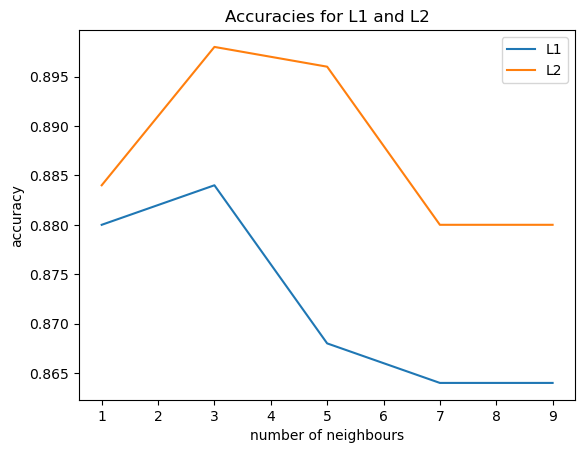

In [115]:
accuracies_l1 = list()
for n in neighbours:
    a = calc_accuracy_score(n, 'l1')
    print(a)
    accuracies_l1.append(a)
accuracies_l1 = np.array(accuracies_l1)


accuracies_l2 = np.loadtxt('acuratete_l2.txt').astype(float)
plt.plot(neighbours, accuracies_l1)
plt.plot(neighbours, accuracies_l2)

plt.xlabel('number of neighbours')
plt.ylabel('accuracy')
plt.legend(['L1', 'L2'])
plt.title('Accuracies for L1 and L2')
plt.show()